In [1]:
import os
import re
import json

# Set the base directory
base_dir = './vgg16_128/outputs'

# Dictionary to store all layer percentages
all_layers_percent = {}

# List all folders that are layer directories (named with two digits)
layer_folders = sorted([d for d in os.listdir(base_dir) if d.isdigit() and len(d) == 2])

for folder_name in layer_folders:
    folder = os.path.join(base_dir, folder_name)
    stat_path = os.path.join(folder, 'timeloop-mapper.stats.txt')

    if not os.path.isfile(stat_path):
        print(f"Warning: {stat_path} not found. Skipping.")
        continue

    with open(stat_path, 'r') as file:
        lines = file.readlines()

    # Locate the 'fJ/Compute' section
    start_index = -1
    for i, line in enumerate(lines):
        if 'fJ/Compute' in line:
            start_index = i + 1
            break

    if start_index == -1:
        print(f"Warning: 'fJ/Compute' section not found in {stat_path}. Skipping.")
        continue

    component_energy = {}
    total_energy = 0.0
    for line in lines[start_index:]:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = re.match(r'^([\w/]+)\s+=\s+([\d.]+)', line)
        if match:
            name = match.group(1)
            if name.lower() == 'total':
                continue  # Skip 'Total' line from component list
            energy = float(match.group(2))
            component_energy[name] = energy
            total_energy += energy
        elif "Total" in line:
            break  # Stop if a general "Total" line is reached after components

    # Calculate and print percentages
    component_energy_percent = {}
    print(f"\nLayer {folder_name} - Total Energy (excluding 'Total' line): {total_energy:.2f} fJ/Compute\n")
    for name, energy in component_energy.items():
        percent = (energy / total_energy) * 100 if total_energy > 0 else 0
        component_energy_percent[name] = percent
        print(f"{name:<35} : {energy:.2f} fJ ({percent:.2f}%)")

    # Store percentages for this layer
    all_layers_percent[folder_name] = component_energy_percent

# Optional: Output all percentages as JSON (nicely formatted)
print("\n=== All Layers Percentage Breakdown ===")
print(json.dumps(all_layers_percent, indent=2))



Layer 00 - Total Energy (excluding 'Total' line): 7128.44 fJ/Compute

mac                                 : 665.77 fJ (9.34%)
output_activation_reg               : 94.95 fJ (1.33%)
input_activation_reg                : 106.82 fJ (1.50%)
weight_reg                          : 106.82 fJ (1.50%)
pe_spad                             : 1.50 fJ (0.02%)
shared_glb                          : 1183.08 fJ (16.60%)
DRAM                                : 4969.50 fJ (69.71%)

Layer 01 - Total Energy (excluding 'Total' line): 2331.99 fJ/Compute

mac                                 : 665.77 fJ (28.55%)
output_activation_reg               : 103.85 fJ (4.45%)
input_activation_reg                : 106.82 fJ (4.58%)
weight_reg                          : 106.82 fJ (4.58%)
pe_spad                             : 97.83 fJ (4.20%)
shared_glb                          : 513.66 fJ (22.03%)
DRAM                                : 737.24 fJ (31.61%)

Layer 02 - Total Energy (excluding 'Total' line): 2843.22 fJ/Compute



In [2]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Folder \tEnergy (J) \tCycles")

    total_energy = 0.0
    total_cycles = 0.0
    total_area = 0.0

    layer_data = []  # For plotting

    for subfolder in sorted(os.listdir(output_dir)):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        folder_energy = 0.0
        folder_cycles = 0.0

        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        folder_energy = float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        folder_cycles = float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        total_energy += folder_energy
        total_cycles += folder_cycles

        # Area only once
        if total_area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        total_area += count * area_per_unit
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")

        print(f"{model} \t {subfolder} \t{folder_energy * 1e-6:.2e} \t{int(folder_cycles)}")

        # Save for plotting
        layer_data.append({
            "Layer": int(subfolder),
            "Energy (uJ)": folder_energy,
            "Cycles": folder_cycles
        })

    # Summary
    total_energy *= 1e-6
    total_area *= 1e-6
    throughput = 1 / (total_cycles * 1e-9) if total_cycles > 0 else 0

    print("\n=== Total Summary ===")
    print("Model \t\tEnergy/inference (J) \tArea (mm²) \tThroughput (inf/s)")
    print("{:s} \t{:.2e} \t\t{:.2f} \t\t{:.2e}".format(model, total_energy, total_area, throughput))

    return layer_data


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_energy_and_cycles_per_layer(layer_data):
    df = pd.DataFrame(layer_data).sort_values("Layer")

    # Plot Energy
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Energy (uJ)"], color='mediumseagreen')
    plt.title("Energy per Layer for vgg16")
    plt.xlabel("Layer")
    plt.ylabel("Energy (uJ)")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()

    # Plot Cycles
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Cycles"], color='steelblue')
    plt.title("Cycles per Layer for vgg16")
    plt.xlabel("Layer")
    plt.ylabel("Cycles")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()


Scanning in: ./vgg16_128/outputs
Model 	 Folder 	Energy (J) 	Cycles
vgg16 	 00 	6.18e-04 	1944320
vgg16 	 01 	4.31e-03 	25604096
vgg16 	 02 	2.63e-03 	11253760
vgg16 	 03 	5.41e-03 	21575680
vgg16 	 04 	2.63e-03 	10787840
vgg16 	 05 	5.37e-03 	21625856
vgg16 	 06 	5.37e-03 	21625856
vgg16 	 07 	2.45e-03 	14597632
vgg16 	 08 	3.69e-03 	21650944
vgg16 	 09 	3.69e-03 	21650944
vgg16 	 10 	1.43e-03 	5412736
vgg16 	 11 	1.43e-03 	5412736
vgg16 	 12 	1.43e-03 	5412736
vgg16 	 13 	1.33e-02 	802816
vgg16 	 14 	2.17e-03 	131072
vgg16 	 15 	5.31e-04 	32000

=== Total Summary ===
Model 		Energy/inference (J) 	Area (mm²) 	Throughput (inf/s)
vgg16 	5.65e-02 		15.43 		5.28e+00


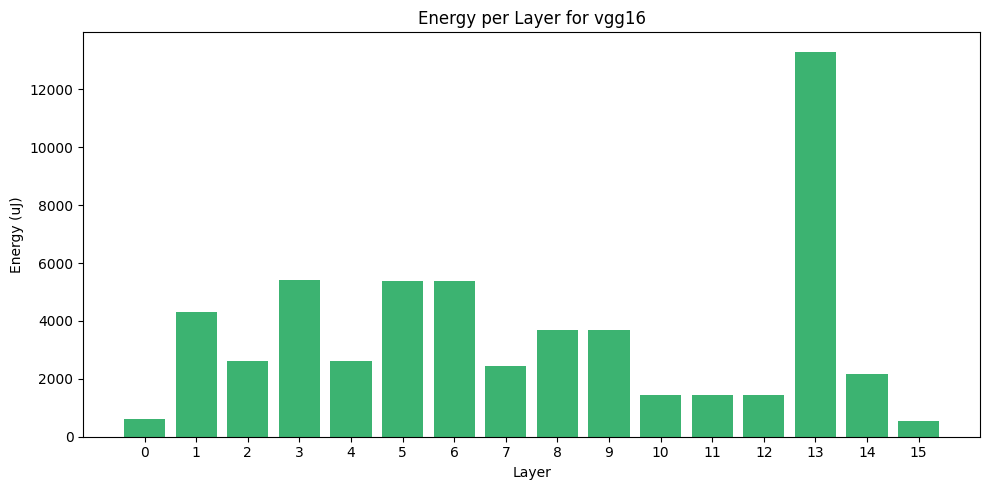

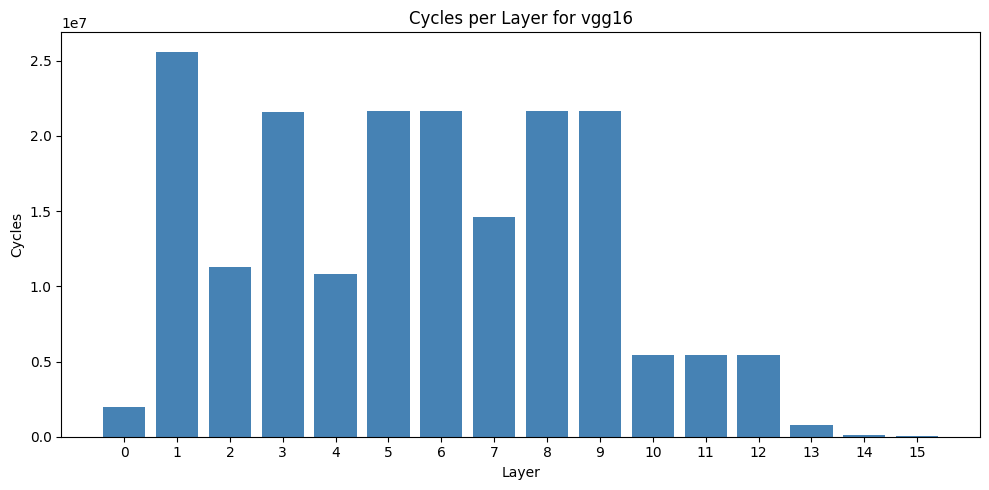

In [4]:
layer_data = extract_outputs("vgg16", "vgg16_128")
plot_energy_and_cycles_per_layer(layer_data)

In [5]:
all_layers_percent

{'00': {'mac': 9.339631111435322,
  'output_activation_reg': 1.331988485559253,
  'input_activation_reg': 1.4985045816475975,
  'weight_reg': 1.4985045816475975,
  'pe_spad': 0.021042472125738593,
  'shared_glb': 16.59661861501254,
  'DRAM': 69.71371015257195},
 '01': {'mac': 28.549436318337555,
  'output_activation_reg': 4.453278101535599,
  'input_activation_reg': 4.580637138238157,
  'weight_reg': 4.580637138238157,
  'pe_spad': 4.195129481687315,
  'shared_glb': 22.02668107496173,
  'DRAM': 31.61420074700149},
 '02': {'mac': 23.416056443046966,
  'output_activation_reg': 3.652548870646661,
  'input_activation_reg': 3.757007899494235,
  'weight_reg': 3.757007899494235,
  'pe_spad': 0.13892699122825528,
  'shared_glb': 16.49925084938907,
  'DRAM': 48.77920104670057},
 '03': {'mac': 22.75553276937537,
  'output_activation_reg': 3.6257369905152528,
  'input_activation_reg': 3.651029650516961,
  'weight_reg': 3.651029650516961,
  'pe_spad': 0.13466632487396393,
  'shared_glb': 18.490301

In [6]:
layer_data

[{'Layer': 0, 'Energy (uJ)': 618.07, 'Cycles': 1944320.0},
 {'Layer': 1, 'Energy (uJ)': 4313.46, 'Cycles': 25604096.0},
 {'Layer': 2, 'Energy (uJ)': 2629.54, 'Cycles': 11253760.0},
 {'Layer': 3, 'Energy (uJ)': 5411.72, 'Cycles': 21575680.0},
 {'Layer': 4, 'Energy (uJ)': 2632.42, 'Cycles': 10787840.0},
 {'Layer': 5, 'Energy (uJ)': 5368.66, 'Cycles': 21625856.0},
 {'Layer': 6, 'Energy (uJ)': 5368.66, 'Cycles': 21625856.0},
 {'Layer': 7, 'Energy (uJ)': 2454.19, 'Cycles': 14597632.0},
 {'Layer': 8, 'Energy (uJ)': 3687.13, 'Cycles': 21650944.0},
 {'Layer': 9, 'Energy (uJ)': 3687.13, 'Cycles': 21650944.0},
 {'Layer': 10, 'Energy (uJ)': 1432.91, 'Cycles': 5412736.0},
 {'Layer': 11, 'Energy (uJ)': 1432.91, 'Cycles': 5412736.0},
 {'Layer': 12, 'Energy (uJ)': 1432.91, 'Cycles': 5412736.0},
 {'Layer': 13, 'Energy (uJ)': 13305.53, 'Cycles': 802816.0},
 {'Layer': 14, 'Energy (uJ)': 2172.6, 'Cycles': 131072.0},
 {'Layer': 15, 'Energy (uJ)': 530.88, 'Cycles': 32000.0}]

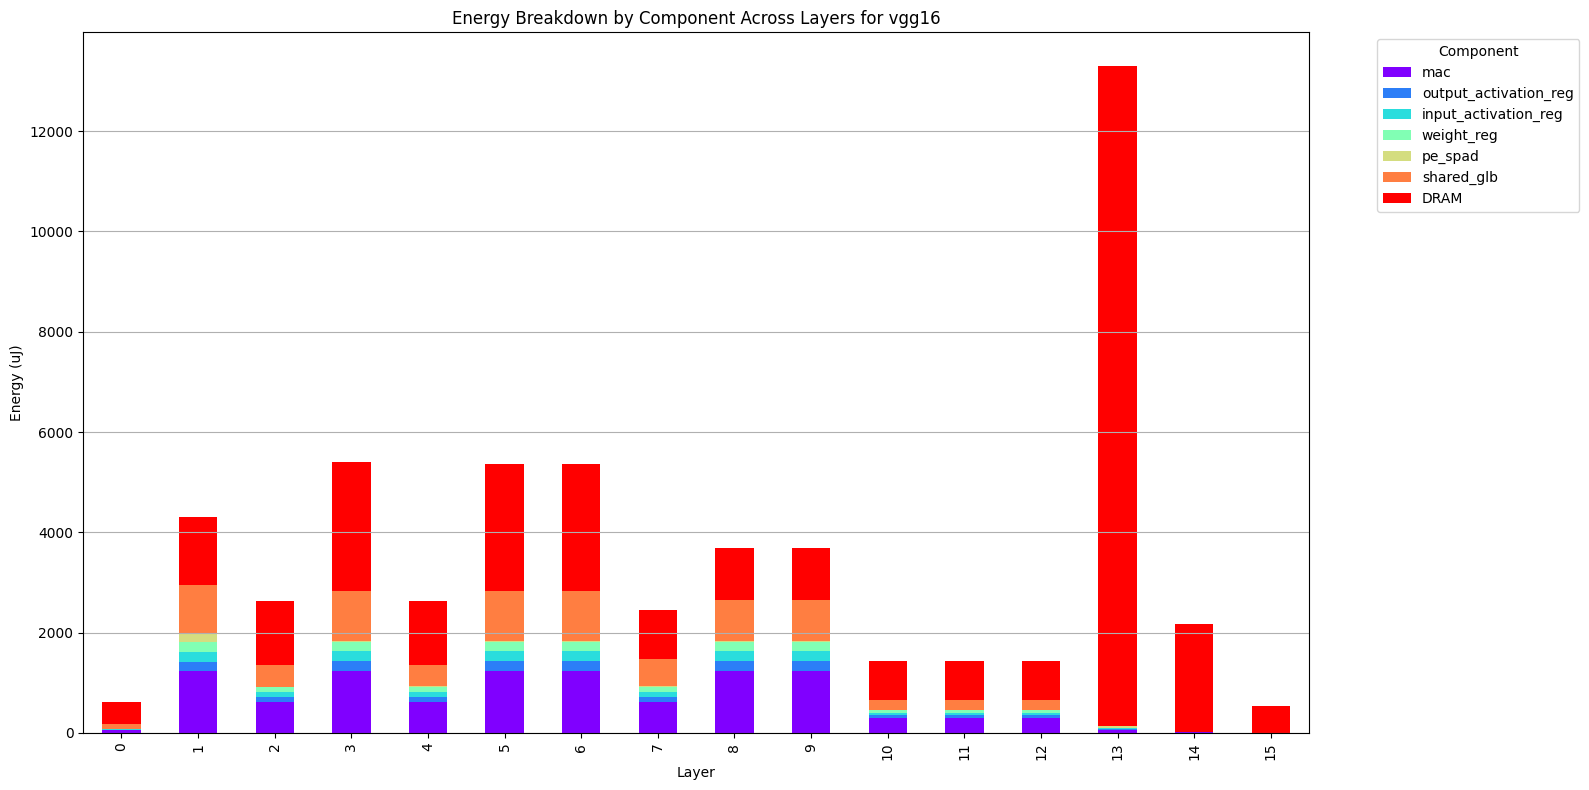

In [7]:
component_energy_by_layer = []
for entry in layer_data:
    layer_index = entry['Layer']
    layer_key = f"{layer_index:02d}"
    total_energy = entry['Energy (uJ)']
    percent_dict = all_layers_percent.get(layer_key, {})
    
    component_energies = {'Layer': layer_index}
    for component, percent in percent_dict.items():
        component_energies[component] = (percent / 100.0) * total_energy
    
    component_energy_by_layer.append(component_energies)

# Convert to DataFrame
df = pd.DataFrame(component_energy_by_layer)
df.set_index('Layer', inplace=True)
df.fillna(0, inplace=True)

# Plot stacked bar chart
from matplotlib import colormaps
import numpy as np
colors = plt.get_cmap('rainbow')(np.linspace(0, 1, df.shape[1]))# You can also use 'Set3', 'nipy_spectral', 'rainbow'
ax = df.plot(kind='bar', stacked=True, figsize=(16, 8), color=colors)

plt.ylabel('Energy (uJ)')
plt.title('Energy Breakdown by Component Across Layers for vgg16')
plt.legend(title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y')
plt.show()